# Student Dropout Prediction Project

## Notebook 03: Baseline Machine Learning Models

### Objective

This notebook trains baseline machine learning models to predict student outcomes.

Two prediction stages are evaluated:

1. **Enrollment-only prediction**
   Uses information available when a student enrolls.

2. **Semester 1 prediction**
   Uses enrollment information together with first-semester academic information.

The target variable contains three classes:

- Dropout
- Enrolled
- Graduate

The baseline models are:

- Logistic Regression
- Decision Tree
- Random Forest

The models are evaluated using accuracy, macro precision, macro recall, macro F1-score, classification reports, and confusion matrices.

This notebook is intentionally focused on baseline performance. Hyperparameter tuning is left for a later stage.


## 1. Import libraries

The notebook is designed to run independently, so all required libraries and feature definitions are created here rather than relying on variables from Notebook 02.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")


## 2. Load the processed datasets

Notebook 01 created the two datasets used for the prediction stages:

- `enrollment_only.csv`
- `semester1.csv`

The target column is `Target`.


In [2]:
enrollment_df = pd.read_csv("../data/processed/enrollment_only.csv")
semester1_df = pd.read_csv("../data/processed/semester1.csv")

print("Enrollment-only shape:", enrollment_df.shape)
print("Semester 1 shape:", semester1_df.shape)


Enrollment-only shape: (4424, 25)
Semester 1 shape: (4424, 31)


## 3. Separate features and target

`Target` is the prediction target and is removed from the feature matrices.

The feature matrices are kept separate for the two prediction stages.


In [3]:
X_enrollment = enrollment_df.drop(columns=["Target"])
y_enrollment = enrollment_df["Target"]

X_semester1 = semester1_df.drop(columns=["Target"])
y_semester1 = semester1_df["Target"]

print("Enrollment-only features:", X_enrollment.shape)
print("Enrollment-only target:", y_enrollment.shape)

print("\nSemester 1 features:", X_semester1.shape)
print("Semester 1 target:", y_semester1.shape)


Enrollment-only features: (4424, 24)
Enrollment-only target: (4424,)

Semester 1 features: (4424, 30)
Semester 1 target: (4424,)


## 4. Define categorical and numerical variables

Several columns contain numerical codes but represent categories. These are treated as categorical variables and one-hot encoded.

Continuous or approximately continuous variables are standardized using `StandardScaler`.


In [4]:
categorical_cols = [
    "Marital Status",
    "Application mode",
    "Application order",
    "Course",
    "Daytime/evening attendance",
    "Previous qualification",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    "Displaced",
    "Educational special needs",
    "Debtor",
    "Tuition fees up to date",
    "Gender",
    "Scholarship holder",
    "International"
]

numerical_cols = [
    "Previous qualification (grade)",
    "Admission grade",
    "Age at enrollment"
]

semester1_numerical_cols = numerical_cols + [
    "Curricular units 1st sem (credited)",
    "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 1st sem (without evaluations)"
]

print("Categorical features:", len(categorical_cols))
print("Enrollment numerical features:", len(numerical_cols))
print("Semester 1 numerical features:", len(semester1_numerical_cols))


Categorical features: 17
Enrollment numerical features: 3
Semester 1 numerical features: 9


## 5. Train-test split

An 80/20 train-test split is used.

Stratification is applied so that the three target classes maintain approximately the same proportions in the training and testing sets.

A fixed random state makes the experiment reproducible.


In [5]:
X_train_enrollment, X_test_enrollment, y_train_enrollment, y_test_enrollment = train_test_split(
    X_enrollment,
    y_enrollment,
    test_size=0.20,
    random_state=42,
    stratify=y_enrollment
)

X_train_semester1, X_test_semester1, y_train_semester1, y_test_semester1 = train_test_split(
    X_semester1,
    y_semester1,
    test_size=0.20,
    random_state=42,
    stratify=y_semester1
)

print("Enrollment-only:")
print("Training:", X_train_enrollment.shape)
print("Testing:", X_test_enrollment.shape)

print("\nSemester 1:")
print("Training:", X_train_semester1.shape)
print("Testing:", X_test_semester1.shape)


Enrollment-only:
Training: (3539, 24)
Testing: (885, 24)

Semester 1:
Training: (3539, 30)
Testing: (885, 30)


## 6. Check target distribution after splitting

The target distribution is checked to confirm that stratification preserved the class proportions.


In [6]:
distribution_check = pd.DataFrame({
    "Original": y_enrollment.value_counts(normalize=True),
    "Training": y_train_enrollment.value_counts(normalize=True),
    "Testing": y_test_enrollment.value_counts(normalize=True)
}).fillna(0)

display((distribution_check * 100).round(2))


,Original,Training,Testing
Target,,,
Graduate,49.9300,49.9300,49.9400
Dropout,32.1200,32.1300,32.0900
Enrolled,17.9500,17.9400,17.9700


## 7. Create preprocessing pipelines

The preprocessing is placed inside each machine learning pipeline.

For categorical variables:

- One-hot encoding is used.
- `handle_unknown="ignore"` prevents errors if a category appears in the test data that was not present in the training data.

For numerical variables:

- Standardization is applied.

Because the preprocessor is inside the pipeline, it is fitted only on the training data.


In [7]:
enrollment_preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        ),
        (
            "num",
            StandardScaler(),
            numerical_cols
        )
    ]
)

semester1_preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        ),
        (
            "num",
            StandardScaler(),
            semester1_numerical_cols
        )
    ]
)


## 8. Define baseline models

Three standard classification algorithms are used.

### Logistic Regression

Provides a linear baseline and is relatively easy to interpret.

### Decision Tree

Provides a non-linear, rule-based baseline.

### Random Forest

Combines multiple decision trees and can capture more complex relationships.

These are baseline configurations, not tuned models.


In [8]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )
}


## 9. Helper function for model evaluation

The function below trains a pipeline, generates predictions, calculates evaluation metrics, and returns the fitted model and predictions.

Macro averaging is used for precision, recall, and F1-score so that each target class contributes equally to the metric.


In [9]:
def evaluate_model(model_name, model, preprocessor, X_train, X_test, y_train, y_test):
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Macro Precision": precision_score(
            y_test, predictions, average="macro", zero_division=0
        ),
        "Macro Recall": recall_score(
            y_test, predictions, average="macro", zero_division=0
        ),
        "Macro F1": f1_score(
            y_test, predictions, average="macro", zero_division=0
        )
    }

    return pipeline, predictions, metrics


## 10. Train and evaluate Enrollment-only models

Only variables available at enrollment are used in this stage.


In [10]:
enrollment_models = {}
enrollment_predictions = {}
enrollment_results = []

for model_name, model in models.items():
    fitted_model, predictions, metrics = evaluate_model(
        model_name,
        model,
        enrollment_preprocessor,
        X_train_enrollment,
        X_test_enrollment,
        y_train_enrollment,
        y_test_enrollment
    )

    enrollment_models[model_name] = fitted_model
    enrollment_predictions[model_name] = predictions
    enrollment_results.append(metrics)

enrollment_results_df = pd.DataFrame(enrollment_results)

display(
    enrollment_results_df.round(4)
)


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,0.6237,0.5281,0.5127,0.5060
1,Decision Tree,0.5220,0.4679,0.4660,0.4666
2,Random Forest,0.6215,0.5294,0.5022,0.4848


## 11. Classification reports for Enrollment-only models

The classification reports show precision, recall, and F1-score separately for Dropout, Enrolled, and Graduate.


In [11]:
for model_name, predictions in enrollment_predictions.items():
    print("=" * 70)
    print(model_name)
    print("=" * 70)
    print(
        classification_report(
            y_test_enrollment,
            predictions,
            labels=["Dropout", "Enrolled", "Graduate"],
            zero_division=0
        )
    )


Logistic Regression
              precision    recall  f1-score   support

     Dropout       0.65      0.60      0.62       284
    Enrolled       0.28      0.12      0.17       159
    Graduate       0.65      0.82      0.73       442

    accuracy                           0.62       885
   macro avg       0.53      0.51      0.51       885
weighted avg       0.59      0.62      0.59       885

Decision Tree
              precision    recall  f1-score   support

     Dropout       0.54      0.51      0.53       284
    Enrolled       0.24      0.26      0.25       159
    Graduate       0.63      0.62      0.62       442

    accuracy                           0.52       885
   macro avg       0.47      0.47      0.47       885
weighted avg       0.53      0.52      0.53       885

Random Forest
              precision    recall  f1-score   support

     Dropout       0.61      0.60      0.60       284
    Enrolled       0.33      0.08      0.12       159
    Graduate       0.65    

## 12. Confusion matrices for Enrollment-only models

A confusion matrix shows the actual class against the predicted class.

The diagonal contains correct predictions. Off-diagonal cells show where the model confuses one outcome with another.


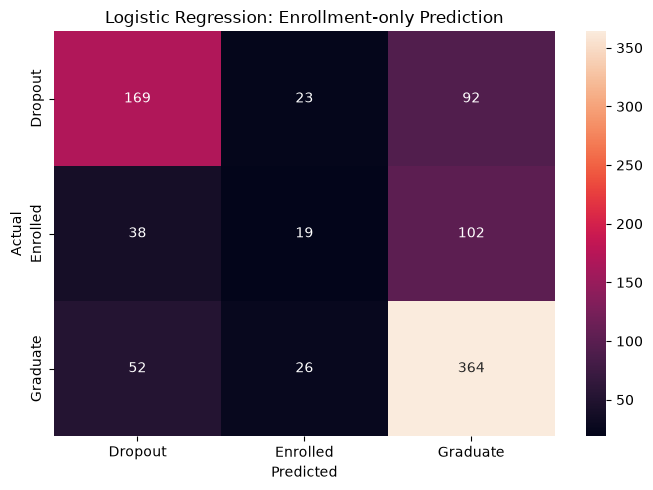

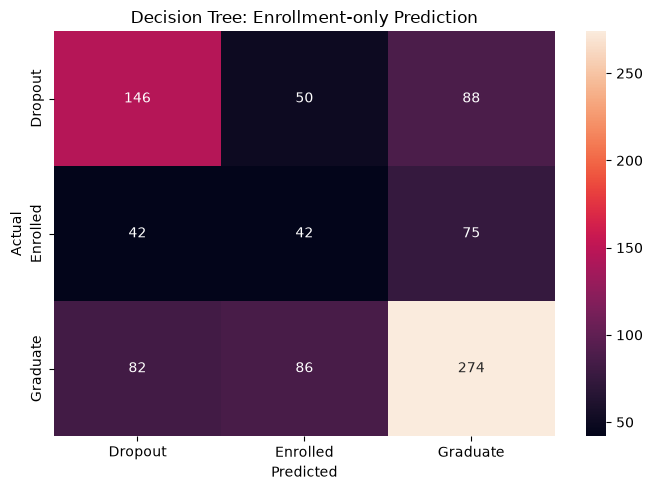

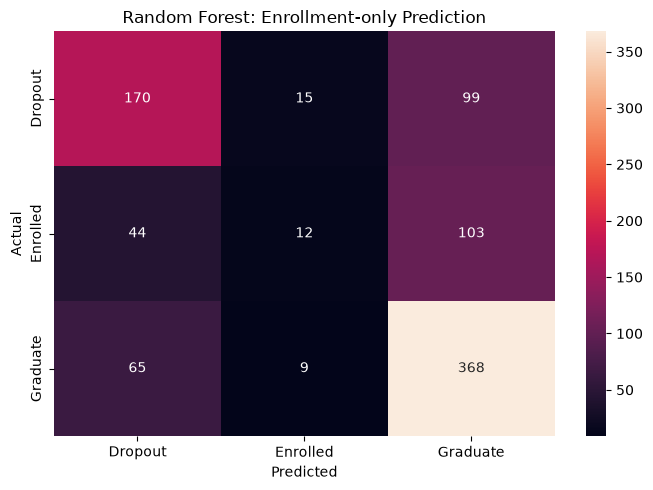

In [12]:
for model_name, predictions in enrollment_predictions.items():
    cm = confusion_matrix(
        y_test_enrollment,
        predictions,
        labels=["Dropout", "Enrolled", "Graduate"]
    )

    plt.figure(figsize=(7, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=["Dropout", "Enrolled", "Graduate"],
        yticklabels=["Dropout", "Enrolled", "Graduate"]
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{model_name}: Enrollment-only Prediction")
    plt.tight_layout()
    plt.show()


## 13. Train and evaluate Semester 1 models

The Semester 1 stage adds first-semester academic information to the enrollment information.

Second-semester variables are not used.


In [13]:
semester1_models = {}
semester1_predictions = {}
semester1_results = []

for model_name, model in models.items():
    fitted_model, predictions, metrics = evaluate_model(
        model_name,
        model,
        semester1_preprocessor,
        X_train_semester1,
        X_test_semester1,
        y_train_semester1,
        y_test_semester1
    )

    semester1_models[model_name] = fitted_model
    semester1_predictions[model_name] = predictions
    semester1_results.append(metrics)

semester1_results_df = pd.DataFrame(semester1_results)

display(
    semester1_results_df.round(4)
)


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,0.7379,0.6651,0.6426,0.6465
1,Decision Tree,0.6610,0.5995,0.6006,0.5999
2,Random Forest,0.7186,0.6284,0.5988,0.5925


## 14. Classification reports for Semester 1 models


In [14]:
for model_name, predictions in semester1_predictions.items():
    print("=" * 70)
    print(model_name)
    print("=" * 70)
    print(
        classification_report(
            y_test_semester1,
            predictions,
            labels=["Dropout", "Enrolled", "Graduate"],
            zero_division=0
        )
    )


Logistic Regression
              precision    recall  f1-score   support

     Dropout       0.77      0.75      0.76       284
    Enrolled       0.45      0.28      0.35       159
    Graduate       0.78      0.89      0.83       442

    accuracy                           0.74       885
   macro avg       0.67      0.64      0.65       885
weighted avg       0.72      0.74      0.72       885

Decision Tree
              precision    recall  f1-score   support

     Dropout       0.64      0.66      0.65       284
    Enrolled       0.38      0.38      0.38       159
    Graduate       0.78      0.76      0.77       442

    accuracy                           0.66       885
   macro avg       0.60      0.60      0.60       885
weighted avg       0.66      0.66      0.66       885

Random Forest
              precision    recall  f1-score   support

     Dropout       0.74      0.72      0.73       284
    Enrolled       0.40      0.16      0.23       159
    Graduate       0.75    

## 15. Confusion matrices for Semester 1 models


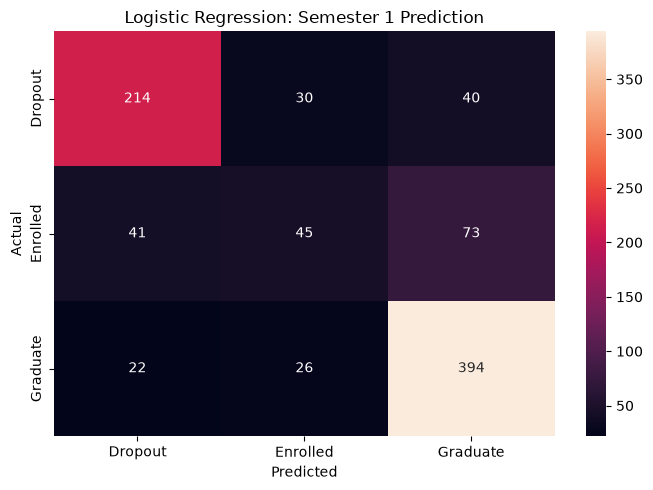

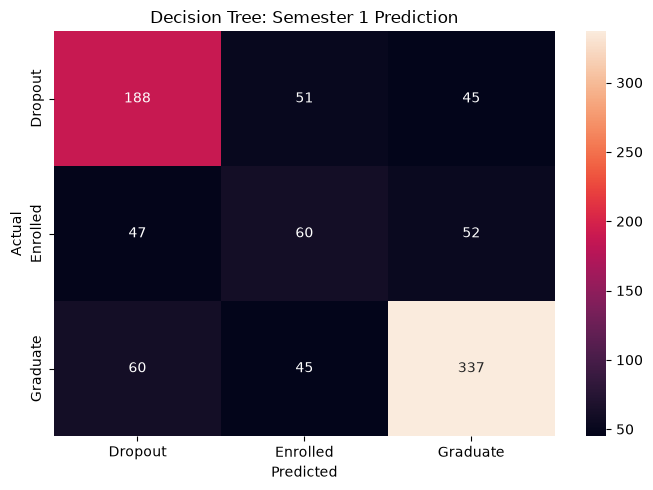

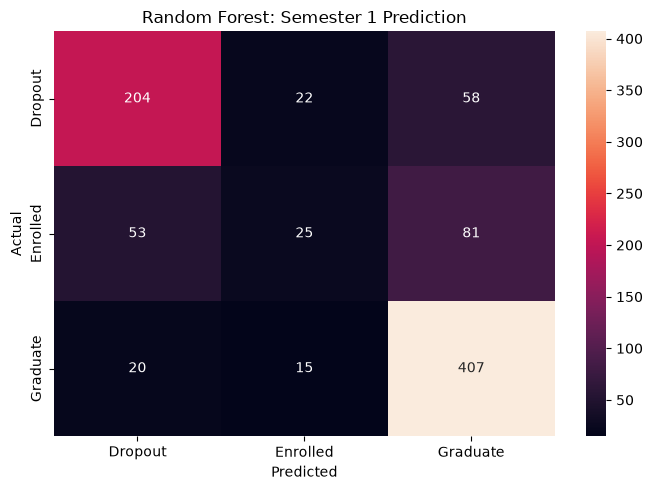

In [15]:
for model_name, predictions in semester1_predictions.items():
    cm = confusion_matrix(
        y_test_semester1,
        predictions,
        labels=["Dropout", "Enrolled", "Graduate"]
    )

    plt.figure(figsize=(7, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=["Dropout", "Enrolled", "Graduate"],
        yticklabels=["Dropout", "Enrolled", "Graduate"]
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{model_name}: Semester 1 Prediction")
    plt.tight_layout()
    plt.show()


## 16. Combine all baseline results

This table allows the two prediction stages to be examined together.

The purpose at this stage is to document baseline performance, not to select a final model yet.


In [16]:
enrollment_results_df["Prediction Stage"] = "Enrollment-only"
semester1_results_df["Prediction Stage"] = "Semester 1"

all_results = pd.concat(
    [enrollment_results_df, semester1_results_df],
    ignore_index=True
)

all_results = all_results[
    [
        "Prediction Stage",
        "Model",
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1"
    ]
]

display(all_results.round(4))


,Prediction Stage,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Enrollment-only,Logistic Regression,0.6237,0.5281,0.5127,0.5060
1,Enrollment-only,Decision Tree,0.5220,0.4679,0.4660,0.4666
2,Enrollment-only,Random Forest,0.6215,0.5294,0.5022,0.4848
3,Semester 1,Logistic Regression,0.7379,0.6651,0.6426,0.6465
4,Semester 1,Decision Tree,0.6610,0.5995,0.6006,0.5999
5,Semester 1,Random Forest,0.7186,0.6284,0.5988,0.5925


## 17. Compare prediction stages by model

This table places the same model in the two prediction stages so that the change in performance can be examined directly.


In [17]:
stage_comparison = all_results.pivot(
    index="Model",
    columns="Prediction Stage",
    values="Macro F1"
)

display(stage_comparison.round(4))


Prediction Stage,Enrollment-only,Semester 1
Model,,
Decision Tree,0.4666,0.5999
Logistic Regression,0.5060,0.6465
Random Forest,0.4848,0.5925


## 18. Baseline findings

### Finding 1: Enrollment-only prediction provides a useful baseline

Using only information available at enrollment, the three baseline models achieved accuracy values between 52.20% and 62.37%.

Logistic Regression achieved a Macro F1-score of 0.5060, Decision Tree achieved 0.4666, and Random Forest achieved 0.4848.

The results show that student outcomes can be predicted to some extent using enrollment information, although performance differs considerably across the three target classes.

### Finding 2: Semester 1 information improves predictive performance

Adding first-semester academic information increased the baseline performance across all three models.

Logistic Regression increased from a Macro F1-score of 0.5060 in the enrollment-only stage to 0.6465 in the Semester 1 stage.

Decision Tree increased from 0.4666 to 0.5999, while Random Forest increased from 0.4848 to 0.5925.

This indicates that first-semester academic information contains substantial additional predictive information about the eventual student outcome.

### Finding 3: The Enrolled class is the most difficult class to identify

The classification reports show that the Enrolled class has substantially lower recall than Dropout and Graduate.

For the Semester 1 Logistic Regression model, recall was 0.75 for Dropout, 0.28 for Enrolled, and 0.89 for Graduate.

Therefore, overall accuracy does not fully describe model behavior. Class-level precision, recall, F1-score, and confusion matrices are necessary for understanding the predictions.

### Finding 4: Graduate and Dropout are identified more effectively than Enrolled

Across the baseline models, the models generally identify Graduate and Dropout students more successfully than Enrolled students.

This is visible in both the classification reports and confusion matrices. The smaller size of the Enrolled class may contribute to this difference, although model behavior and class overlap also need to be considered.

### Finding 5: Baseline results establish a reference for later modelling

These results provide a baseline against which later model improvements can be evaluated.

The next stage will examine model performance in more detail and investigate whether changes in model configuration or hyperparameters can improve the classification of the three student outcomes.

## 19. Next step

The baseline models are now established.

The next stage is model evaluation and comparison, followed by feature interpretation and, if appropriate, hyperparameter tuning.

The baseline results should be preserved before tuning so that later improvements can be compared against a fixed reference.
